In [1]:
from PIL import Image

# Preprocess

In [2]:
def preprocess_image_center_crop(pil_img, size=(224, 224)):
    # 1. 计算缩放比例，使较短的一边达到 224
    width, height = pil_img.size
    aspect_ratio = width / height
    
    if width > height:
        new_height = size[1]
        new_width = int(new_height * aspect_ratio)
    else:
        new_width = size[0]
        new_height = int(new_width / aspect_ratio)
        
    # 2. 第一次等比例缩放
    pil_img = pil_img.resize((new_width, new_height), Image.Resampling.LANCZOS)
    
    # 3. 计算中心裁剪坐标
    left = (new_width - size[0]) / 2
    top = (new_height - size[1]) / 2
    right = (new_width + size[0]) / 2
    bottom = (new_height + size[1]) / 2
    
    # 4. 执行裁剪
    return pil_img.crop((left, top, right, bottom))


In [3]:
input_img = Image.open("/home/zhenghuang/forgery_detection/gradio_demo/examples/077.png")
processed_img = preprocess_image_center_crop(input_img)
processed_img.save("debug_output.png")

# Load SFMM

In [17]:
import yaml
import torch
from models.dfb import ClipMultiDetector
from torchvision import transforms as T
import numpy as np
from scipy.ndimage import gaussian_filter
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [5]:
def init_sfmm_model(device = 'cuda:1'):
    
    model_config = './checkpoints/sfmm/clip_freq_multi_contrast.yaml'
    with open(model_config, 'r') as f:
        config = yaml.safe_load(f)

    model = ClipMultiDetector(config).to(device)
    weights_path = './checkpoints/sfmm/ckpt_best.pth'
    ckpt = torch.load(weights_path, map_location=device) 
    model.load_state_dict(ckpt, strict=True)
    
    return model

def preprocess(image):
    def normalize(img):
        mean = [0.5, 0.5, 0.5]
        std = [0.5, 0.5, 0.5]
        normalize = T.Normalize(mean=mean, std=std)
        return normalize(img)

    image = np.array(image)
    image_trans = normalize(T.ToTensor()(image))
    
    return image_trans

In [6]:
sfmm_model = init_sfmm_model()

frequency patch size 56
frequency num positions 18


In [7]:
device = 'cuda:1'
image = processed_img
image = preprocess(image).unsqueeze(0).to(device)

In [8]:
sfmm_output = sfmm_model({'image':image, 'label':torch.tensor(1)}, inference=True)

12 torch.Size([1, 3, 224, 224])


In [12]:
def gaussian_attention_map(attention_map, kernel_size=3, sigma=5):
    attention_map = attention_map.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    # smooth_attention_map = F.avg_pool2d(attention_map, kernel_size=kernel_size, stride=1, padding=kernel_size//2)
    
    attention_map = F.interpolate(attention_map, [224,224])
    attention_map = gaussian_filter(attention_map[0, 0].cpu().numpy(), sigma=sigma)
    
    # Normalize the blurred attention map
    attention_map = torch.from_numpy(attention_map)
    attention_map /= attention_map.sum()

    smooth_attention_map = attention_map.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions back

    
    return smooth_attention_map.squeeze().numpy()

def smooth_attention_map(attention_map):
    attention_map = attention_map.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    attention_map /= attention_map.sum()
    attention_map *= 16
    print('freq_attn', attention_map)
    attention_map = F.interpolate(attention_map, [224,224])
    
    return attention_map.squeeze()

In [26]:
def analyze_sfmm_attention(sfmm_output):
    attention = sfmm_output['attentions'][0].squeeze(0).detach().cpu()

    fig, axs = plt.subplots(1, 4, figsize=(10, 3))
    avg_attention = attention.mean(dim=0)

    spatial_attention_map = avg_attention[1][2:198].view(14, 14)
    smooth_spatial_attention_map = gaussian_attention_map(spatial_attention_map)

    freq_to_space_attn_map = avg_attention[200:].mean(dim=0)[2:198].view(14, 14)
    smooth_freq_to_space_attn_map = gaussian_attention_map(freq_to_space_attn_map)


    spa_to_space_attn_map = avg_attention[2:198].mean(dim=0)[2:198].view(14, 14)
    smooth_spa_to_space_attn_map = gaussian_attention_map(spa_to_space_attn_map)

    raw_img = input_img

    axs[0].imshow(raw_img)
    axs[0].set_title('Input Image')
    axs[1].imshow(raw_img, alpha=0.5)
    axs[1].set_title('[SPE] Tokens')
    axs[1].imshow(smooth_spatial_attention_map, cmap='coolwarm', alpha=0.5)
    # axs[2].imshow(fft_img)
    # axs[2].set_title('Frequency')
    # axs[3].imshow(fft_img, alpha=0.5)
    # axs[3].imshow(freq_attention_map, cmap='coolwarm', alpha=0.5)
    axs[2].imshow(raw_img, alpha=0.5)
    axs[2].imshow(smooth_spa_to_space_attn_map, cmap='coolwarm', alpha=0.5)
    axs[2].set_title('Spatial Tokens')

    axs[3].imshow(raw_img, alpha=0.5)
    axs[3].imshow(smooth_freq_to_space_attn_map, cmap='coolwarm', alpha=0.5)
    axs[3].set_title('Freqency Tokens')

    for ax in axs:
        ax.axis('off')

    save_path = f'./outputs/test.png'
    fig.savefig(save_path)
    
    return save_path

'./outputs/test.png'

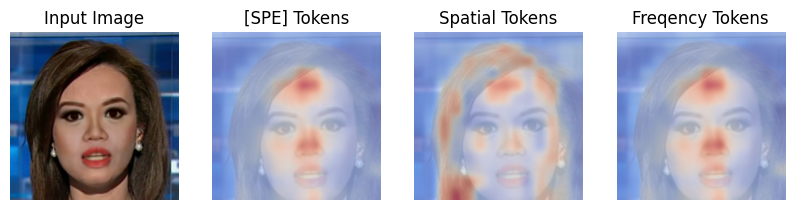

In [27]:
analyze_sfmm_attention(sfmm_output)

In [29]:
sfmm_output['prob']

tensor([0.9999], device='cuda:1', grad_fn=<SelectBackward0>)

# Load SAFE-DF

In [1]:
import argparse
import torch
import os
import json
from tqdm import tqdm
import shortuuid

from models.llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from models.llava.conversation import conv_templates, SeparatorStyle
from models.llava.model.builder import load_pretrained_model
from models.llava.utils import disable_torch_init
from models.llava.mm_utils import tokenizer_image_token, process_images, get_model_name_from_path
from models.llava.model.multimodal_encoder.forgery_clip_encoder import ForgeryCLIPVisionTower
from PIL import Image

/home/zhenghuang/.conda/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2025-12-29 12:35:58,498] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/zhenghuang/.conda/envs/llava/lib/python3.10/site-packages/deepspeed/accelerator/cuda_accelerator.py:33: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/home/zhenghuang/.conda/envs/llava/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/zhenghuang/.conda/envs/llava/lib/python3.10/site-packages/pydantic/_internal/_

In [6]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

device='cuda'
model_path = './checkpoints/llava-1.5-finetune_merged_ff'
model_path = os.path.expanduser(model_path)
model_name = get_model_name_from_path(model_path)
print(f'MODELVQA, loading model from {model_path}')
model_base = None
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path, model_base, model_name,device=device)

MODELVQA, loading model from ./checkpoints/llava-1.5-finetune_merged_ff
load_pretrain_model: model_path==./checkpoints/llava-1.5-finetune_merged_ff, model_base==None, model_name==llava-1.5-finetune_merged_ff
Loading LLava model, model_name==llava-1.5-finetune_merged_ff, model_base==None
---LlavaLlamaForCausalLM---
LlavaConfig {
  "_name_or_path": "./checkpoints/llava-1.5-finetune_merged_ff",
  "architectures": [
    "LlavaLlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "eos_token_id": 2,
  "freeze_mm_mlp_adapter": false,
  "freeze_mm_vision_resampler": false,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "image_aspect_ratio": "pad",
  "initializer_range": 0.02,
  "intermediate_size": 11008,
  "max_length": 4096,
  "max_position_embeddings": 4096,
  "mm_hidden_size": 1024,
  "mm_patch_merge_type": "flat",
  "mm_projector_lr": 2e-05,
  "mm_projector_type": "mlp2x_gelu",
  "mm_resampler_type": null,
  "mm_use_im_patch_token": false,


Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.09it/s]
Some weights of the model checkpoint at ./checkpoints/llava-1.5-finetune_merged_ff were not used when initializing LlavaLlamaForCausalLM: ['model.vision_tower.vision_tower.vision_model.embeddings.class_embedding', 'model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.weight', 'model.vision_tower.vision_tower.vision_model.embeddings.position_embedding.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm2.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm2.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.mlp.fc1.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.mlp.fc1.weight', 'model.vision_tower.vision_tower.vision_model.encoder.la

Image_Processor: CLIPImageProcessor {
  "crop_size": {
    "height": 336,
    "width": 336
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessor",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 336
  }
}



In [3]:
# image_file = line["image"]
qs = 'Is this image real/fake?'
qs = DEFAULT_IMAGE_TOKEN + '\n' + qs

conv = conv_templates['llava_v1'].copy()
conv.append_message(conv.roles[0], qs)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()

input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to(device)


img_path = '/home/zhenghuang/forgery_detection/gradio_demo/examples/077.png'
image = Image.open(os.path.join(img_path, img_path)).convert('RGB')
image_tensor = process_images([image], image_processor, model.config)[0].unsqueeze(0).half().to(device)

with torch.inference_mode():
    print(model.device, device, image_tensor.device, input_ids.device)
    model.model.vision_tower.to(device)
    model.model.vision_tower.mask = None
    output_ids = model.generate(
        input_ids,
        images=image_tensor,
        image_sizes=[image.size],
        do_sample=True,
        temperature=0.5,
        top_p=None,
        num_beams=1,
        # no_repeat_ngram_size=3,
        max_new_tokens=256,
        use_cache=True)
outputs = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0].strip()

print(outputs)

cuda:0 cuda cuda:0 cuda:0


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:1 and cuda:0! (when checking argument for argument weight in method wrapper_CUDA__native_layer_norm)

# Prepare CDF input

In [4]:
import json
import random
import os

In [10]:
input_json = '/home/zhenghuang/forgery_detection/DeepfakeBench/preprocessing/dataset_json/DFDC.json'

data = json.load(open(input_json, 'r'))

input_data = data['DFDC']

label_dict = {'real': 'DFDC_Real', 'fake': 'DFDC_Fake'}

In [22]:
test_data = []

for input_idx in input_data[label_dict['real']]['test'].keys():
    one_data = {"question_id": "", "image": "", "text": "<image>\n Does the image look real/fake?", "category": "default", "gt": ""}
    raw_path = '/home/zhenghuang/forgery_detection/data'
    img_path = os.path.join(raw_path, input_data[label_dict['real']]['test'][input_idx]['frames'][0].replace('\\', '/'))
    one_data["question_id"] = input_idx
    one_data["image"] = img_path
    one_data["gt"] = 'real'
    test_data.append(one_data)

    
for input_idx in input_data[label_dict['fake']]['test'].keys():
    one_data = {"question_id": "", "image": "", "text": "<image>\n Does the image look real/fake?", "category": "default", "gt": ""}
    raw_path = '/home/zhenghuang/forgery_detection/data'
    img_path = os.path.join(raw_path, input_data[label_dict['fake']]['test'][input_idx]['frames'][0].replace('\\', '/'))
    one_data["question_id"] = input_idx
    one_data["image"] = img_path
    one_data["gt"] = 'fake'
    test_data.append(one_data)


In [25]:
test_data_sampled = random.choices(test_data, k=1000)
with open('/home/zhenghuang/forgery_detection/data/llava_format/evaluation_format/dfdc_test.jsonl', 'w') as f:
    for item in test_data_sampled:
        f.write(json.dumps(item) + '\n')

In [26]:
input_json = '/home/zhenghuang/forgery_detection/DeepfakeBench/preprocessing/dataset_json/Celeb-DF-v1.json'

data = json.load(open(input_json, 'r'))

input_data = data['Celeb-DF-v1']

label_dict = {'real': 'CelebDFv1_real', 'fake': 'CelebDFv1_fake'}

test_data = []

for input_idx in input_data[label_dict['real']]['test'].keys():
    one_data = {"question_id": "", "image": "", "text": "<image>\n Does the image look real/fake?", "category": "default", "gt": ""}
    raw_path = '/home/zhenghuang/forgery_detection/data'
    img_path = os.path.join(raw_path, input_data[label_dict['real']]['test'][input_idx]['frames'][0].replace('\\', '/'))
    one_data["question_id"] = input_idx
    one_data["image"] = img_path
    one_data["gt"] = 'real'
    test_data.append(one_data)
print(len(test_data))
    
for input_idx in input_data[label_dict['fake']]['test'].keys():
    one_data = {"question_id": "", "image": "", "text": "<image>\n Does the image look real/fake?", "category": "default", "gt": ""}
    raw_path = '/home/zhenghuang/forgery_detection/data'
    img_path = os.path.join(raw_path, input_data[label_dict['fake']]['test'][input_idx]['frames'][0].replace('\\', '/'))
    one_data["question_id"] = input_idx
    one_data["image"] = img_path
    one_data["gt"] = 'fake'
    test_data.append(one_data)


print(len(test_data))
test_data_sampled = random.choices(test_data, k=1000)
with open('/home/zhenghuang/forgery_detection/data/llava_format/evaluation_format/cdf1_test.jsonl', 'w') as f:
    for item in test_data_sampled:
        f.write(json.dumps(item) + '\n')

38
100


In [5]:
input_json = '/home/zhenghuang/forgery_detection/DeepfakeBench/preprocessing/dataset_json/Celeb-DF-v2.json'

data = json.load(open(input_json, 'r'))

input_data = data['Celeb-DF-v2']

label_dict = {'real': 'CelebDFv2_real', 'fake': 'CelebDFv2_fake'}

test_data = []

for input_idx in input_data[label_dict['real']]['test'].keys():
    one_data = {"question_id": "", "image": "", "text": "<image>\n Does the image look real/fake?", "category": "default", "gt": ""}
    raw_path = '/home/zhenghuang/forgery_detection/data'
    img_path = os.path.join(raw_path, input_data[label_dict['real']]['test'][input_idx]['frames'][0].replace('\\', '/'))
    one_data["question_id"] = input_idx
    one_data["image"] = img_path
    one_data["gt"] = 'real'
    test_data.append(one_data)
print(len(test_data))
    
for input_idx in input_data[label_dict['fake']]['test'].keys():
    one_data = {"question_id": "", "image": "", "text": "<image>\n Does the image look real/fake?", "category": "default", "gt": ""}
    raw_path = '/home/zhenghuang/forgery_detection/data'
    img_path = os.path.join(raw_path, input_data[label_dict['fake']]['test'][input_idx]['frames'][0].replace('\\', '/'))
    one_data["question_id"] = input_idx
    one_data["image"] = img_path
    one_data["gt"] = 'fake'
    test_data.append(one_data)


print(len(test_data))
test_data_sampled = random.choices(test_data, k=1000)
with open('/home/zhenghuang/forgery_detection/data/llava_format/evaluation_format/cdf2_test.jsonl', 'w') as f:
    for item in test_data_sampled:
        f.write(json.dumps(item) + '\n')

178
518
